# 06 — Gen-origin composition and cosmic-veto inputs

Two independent validation streams from the same campaign. (1) **Where do the
background muons come from?** Simulation records which generated particle each
reconstructed lepton matches — NanoAOD's `genPartFlav`: prompt (from the hard
interaction), from a b- or c-hadron decay, from a light-hadron decay or
*decay-in-flight* (a pion or kaon decaying to a muon inside the detector), from a
tau, or unmatched (a misreconstruction); DSA muons carry no match, giving a
DSA-only category. Why this matters for ABCD: the method transports background
from the sidebands into the signal region, and if the sidebands are (say) b-decay
muons while the signal region is decay-in-flight muons, the transported
prediction carries the wrong physics even when the total rates happen to
factorize — composition stability across the plane is the microscopic version of
the independence gate. The sentinel population's composition also directly tests
whether it is the same physics as the jet-matched low-isolation background (the
round-2 hypothesis of the plane-choice study). (2) **Is the cosmic veto signal-safe?**
Simulation contains no cosmics, so MC cannot measure the veto's rejection power —
but it measures exactly what the veto would COST: the fraction of signal with a
back-to-back muon partner (cos α ≈ −1) or a large dz spread inside the LJ.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

sys.path.insert(0, os.getcwd())
import abcd_tools as at
import study_setup as ss

import plot_helpers as ph

hep.style.use("CMS")
plt.rcParams["figure.figsize"] = (9, 7)
# even-parity half of the sample = half the effective luminosity
LUMI_LABEL = ph.LUMI_EVEN
cms_label = ph.cms_label

# pre-skim / pre-filter sums of gen weights (see README "Normalization")
SUMW_PRE = {}
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_2MU2E))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_4MU))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_BKG_UNSKIMMED))
SUMW_PRE.update(ss.SUMW_PRE_OVERRIDES)   # DY rogue-file repair (see study_setup)

# normalization tripwire: a factor outside [1e-5, 1] means a broken denominator
for _s in ss.ANALYSIS_BACKGROUNDS:
    _f = ss.fetch(_s)["metadata"]["scaled_sum_weights"] / SUMW_PRE[_s] / ss.FW.get(_s, 1.0)
    assert 1e-5 < _f <= 1.0, f"normalization factor out of range for {_s}: {_f:.3g}"

# Background sums built ONE SAMPLE AT A TIME (holding all 44 samples in memory OOMs
# the interactive node); signals are loaded lazily where needed, one at a time.
# TTJets kept at the campaign 471.7 pb; the NNLO alternative is an explicit rescale.
total_bkg, by_process = ss.accumulate_normalized(list(ss.ANALYSIS_BACKGROUNDS), SUMW_PRE)
def load_sig(s):
    return ss.load_normalized(s, SUMW_PRE)[0]
print(f"accumulated {len(ss.ANALYSIS_BACKGROUNDS)} background samples "
      f"(DYJetsToMuMu_M50 excluded); scan hists: {len(total_bkg)}")

# round-2 member campaign: identical normalization, second merged-output set
total_bkg_m, by_process_m = ss.accumulate_normalized(
    list(ss.ANALYSIS_BACKGROUNDS), SUMW_PRE, keep_prefix="abcd_",
    eos_dir=ss.EOS_MERGED_MEMBER, tag=".member")
def load_sig_m(s):
    return ss.load_normalized(s, SUMW_PRE, eos_dir=ss.EOS_MERGED_MEMBER, tag=".member")[0]
def member1d(hists, hname, ch, axname):
    hh = at.get_channel(hists[hname], ss.CHANNELS[ch])
    vals, var, xe, ye = at.project_plane(hh, axname, "parity", {})
    return vals[:, 0], xe   # even half
SIG_SHOW = {"2mu2e": ["2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_1000GeV_1p2GeV_0p96mm",
                      "2Mu2E_100GeV_1p2GeV_9p6mm"],
            "4mu": ["4Mu_500GeV_1p2GeV_1p9mm", "4Mu_1000GeV_1p2GeV_0p96mm",
                    "4Mu_100GeV_1p2GeV_9p6mm"]}
print(f"member campaign accumulated: {sorted(n for n in total_bkg_m)}")

accumulated 17 background samples (DYJetsToMuMu_M50 excluded); scan hists: 8


member campaign accumulated: ['abcd_cosmic_2mu2e', 'abcd_cosmic_4mu', 'abcd_member_2mu2e', 'abcd_member_4mu', 'abcd_mother_2mu2e', 'abcd_mother_4mu']


## Mu-LJ gen origin along the isolation axis

Column-normalized composition per jet-isolation bin (even half, preselection),
leftmost column = the sentinel (no matched jet) population. Flat composition =
the isolation axis does not sculpt physics origin; the sentinel column's
similarity to the low-isolation columns is the direct composition test of
treating them together.

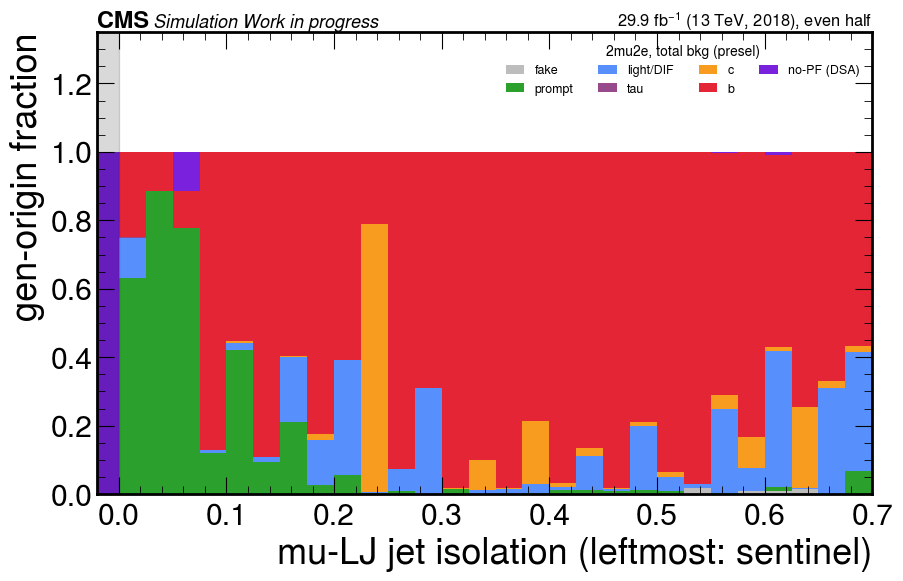

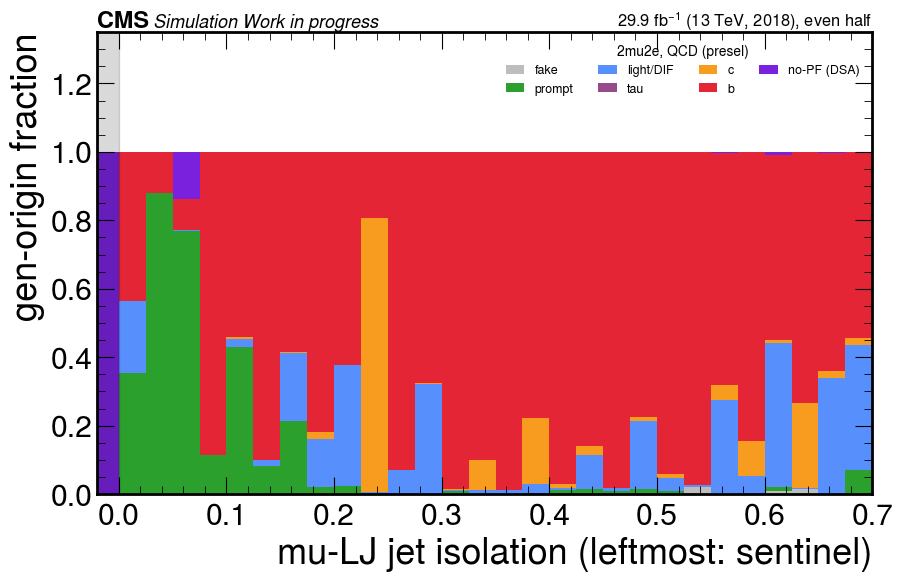

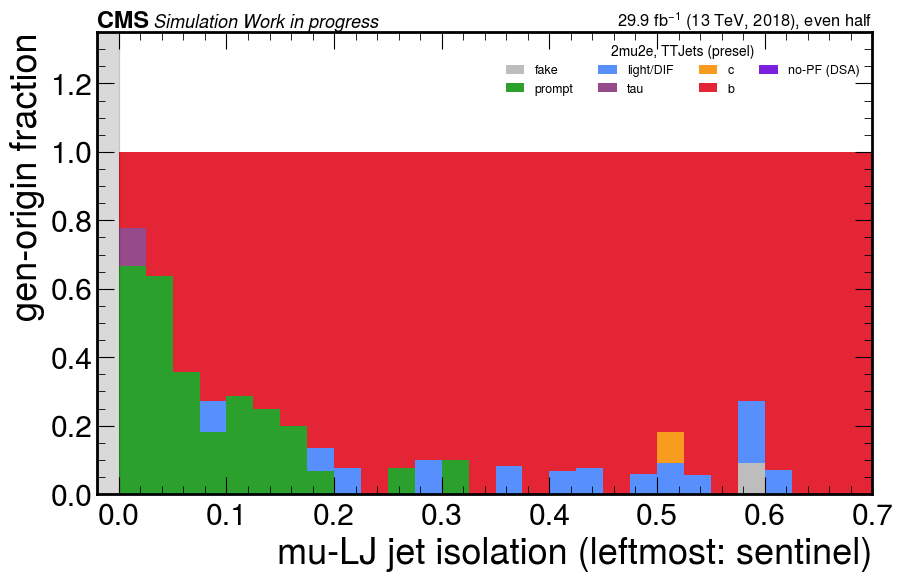

In [2]:
CATS = ["fake", "prompt", "light/DIF", "tau", "c", "b", "no-PF (DSA)"]
CAT_COLORS = ["#bdbdbd", "#2ca02c", "#5790fc", "#964a8b", "#f89c20", "#e42536", "#7a21dd"]
def mother_vs(hists, ch, axis, sel=None):
    hname = "abcd_mother_2mu2e" if ch == "2mu2e" else "abcd_mother_4mu"
    hh = at.get_channel(hists[hname], ss.CHANNELS[ch])
    s = dict(sel or {})
    s["parity"] = ("bin", 0)
    vals, var, xe, ye = at.project_plane(hh, "mother" if ch == "2mu2e" else "mother0",
                                         axis, s)
    return vals, xe, ye

for label, hists in [("total bkg", total_bkg_m), ("QCD", by_process_m["QCD"]),
                     ("TTJets", by_process_m["TTJets"])]:
    vals, xe, ye = mother_vs(hists, "2mu2e", "muiso")
    colsum = vals.sum(axis=0, keepdims=True)
    frac = np.where(colsum > 0, vals / np.maximum(colsum, 1e-300), 0.0)
    fig, axx = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(frac.shape[1])
    for ci in range(7):
        axx.stairs(bottom + frac[ci], ye, baseline=bottom, fill=True,
                   color=CAT_COLORS[ci], label=CATS[ci])
        bottom = bottom + frac[ci]
    axx.axvspan(ye[0], ye[1], color="k", alpha=0.15, zorder=5)
    axx.set_xlim(-0.02, 0.7)
    axx.set_ylim(0, 1.35)
    axx.set_xlabel("mu-LJ jet isolation (leftmost: sentinel)")
    axx.set_ylabel("gen-origin fraction")
    axx.legend(title=f"2mu2e, {label} (presel)", fontsize=9, title_fontsize=10,
               ncol=4, framealpha=0.85, loc="upper right")
    cms_label(axx)
    plt.show()

## Composition across the muiso × mJJ regions

The same categories aggregated in the four ABCD regions of the primary plane, at
the **signal-region working point** actually chosen in notebook 04 (muiso < 0.5,
mJJ ≥ 50; even half). For ABCD the diagnostic is not that the four columns look
alike — they need not — but that the *change from tight to loose isolation* be the
same at high mJJ (A→B) and at low mJJ (C→D). The Findings read that off
quantitatively: it holds for the dominant prompt and b components and breaks for
the subdominant c and light/DIF ones (small, and possibly stat noise on this
partial even-half merge). Each LJ is labeled by the highest-priority gen match
among its muons (b > c > tau > light/DIF > prompt > fake), so a single b-matched
muon tags the whole LJ — "b-dominated" is partly a labeling convention, and the
fake fractions are lower bounds.

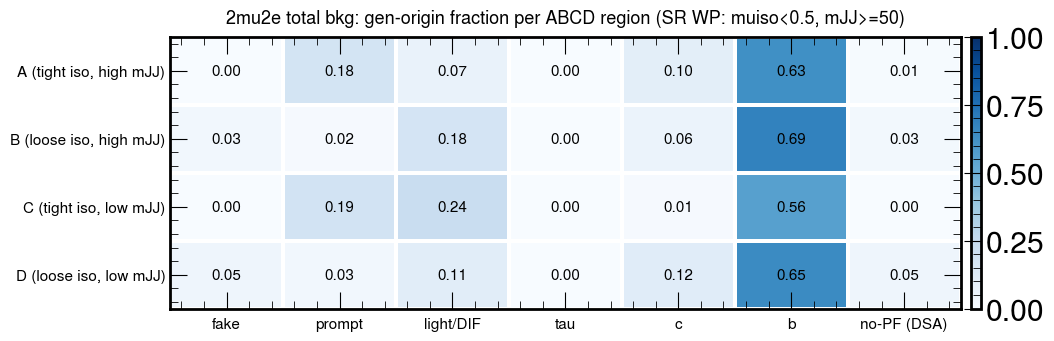

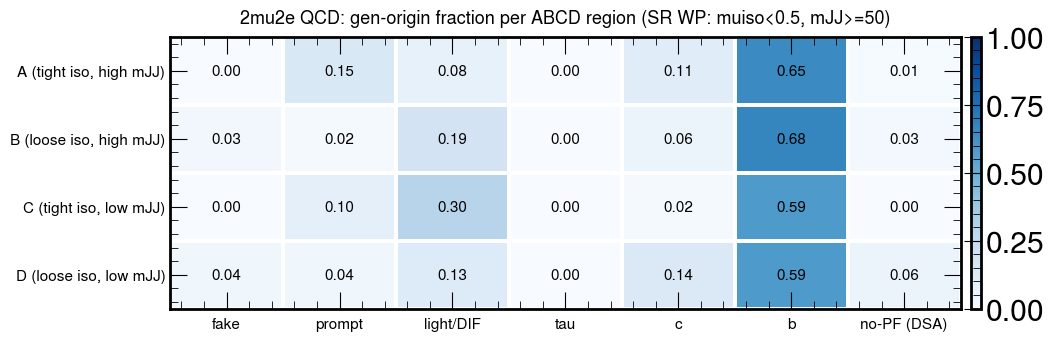

In [3]:
# Regions at the SR working point actually chosen in notebook 04 (the loosest
# healthy rung: muiso < 0.5, mJJ >= 50 GeV), not the nominal plane boundaries.
REG = {"A (tight iso, high mJJ)": (("lt", 0.5), ("ge", 50.0)),
       "B (loose iso, high mJJ)": (("ge", 0.5), ("ge", 50.0)),
       "C (tight iso, low mJJ)": (("lt", 0.5), ("lt", 50.0)),
       "D (loose iso, low mJJ)": (("ge", 0.5), ("lt", 50.0))}
for label, hists in [("total bkg", total_bkg_m), ("QCD", by_process_m["QCD"])]:
    hh = at.get_channel(hists["abcd_mother_2mu2e"], ss.CHANNELS["2mu2e"])
    mat = []
    for rname, (xs, ysel) in REG.items():
        sel = {"muiso": xs, "mjj": ysel, "parity": ("bin", 0)}
        vals, var, xe, ye = at.project_plane(hh, "mother", "mjj",
                                             {"muiso": xs, "parity": ("bin", 0)})
        ymask_lo = at.edge_index(ye, 50.0)
        col = vals[:, ymask_lo:].sum(axis=1) if ysel[0] == "ge" else vals[:, :ymask_lo].sum(axis=1)
        tot = col.sum()
        mat.append(col / tot if tot > 0 else np.full(7, np.nan))
    ph.matrix_heatmap(np.array(mat), list(REG), CATS,
                      f"2mu2e {label}: gen-origin fraction per ABCD region "
                      f"(SR WP: muiso<0.5, mJJ>=50)",
                      cmap="Blues", vmin=0, vmax=1, fmt="{:.2f}")

## Signal muons' gen origin vs lifetime

Displaced signal muons progressively lose their gen match (and their PF
reconstruction): the prompt fraction falls and the unmatched/DSA-only fractions
rise with cτ — useful context for what "fake" means in the background tables.

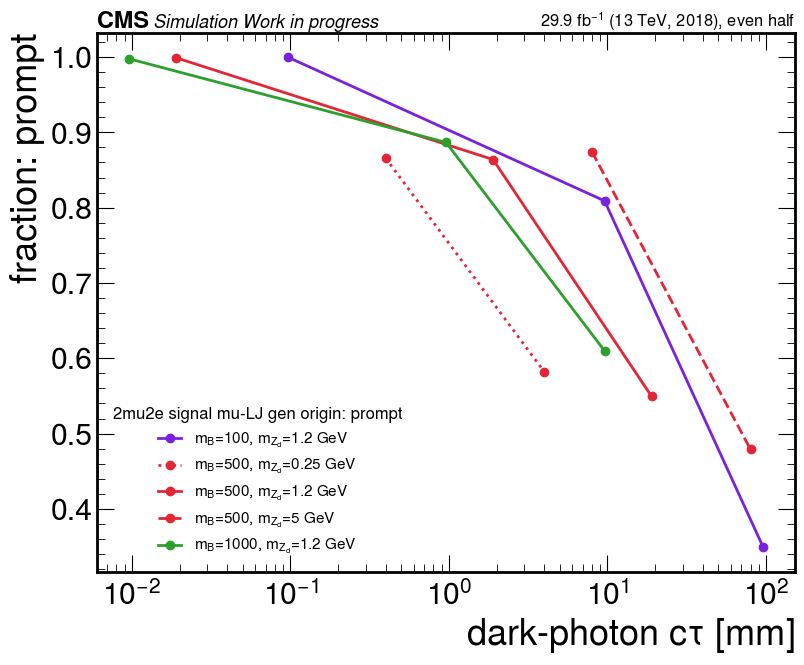

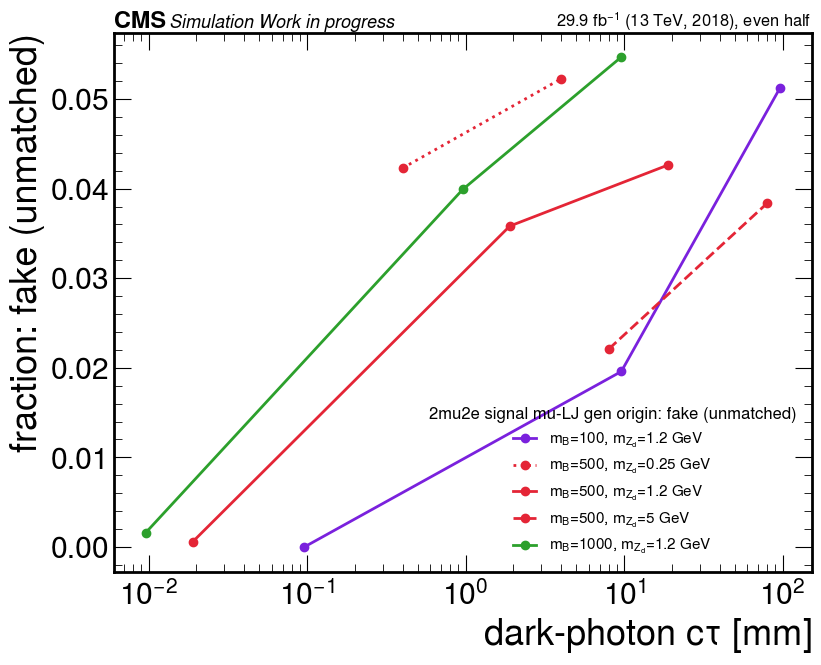

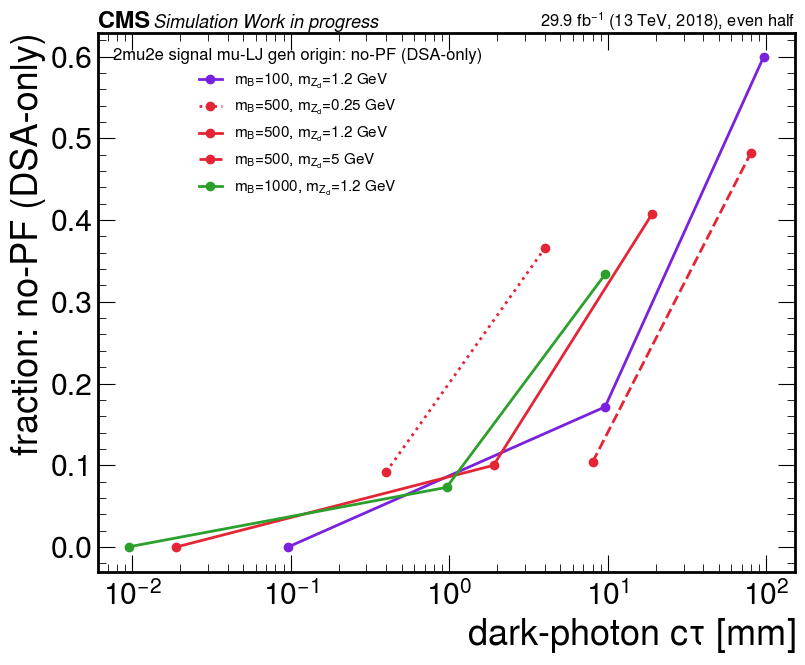

In [4]:
series = {"prompt": {}, "fake (unmatched)": {}, "no-PF (DSA-only)": {}}
for sname in ss.SIGNALS_2MU2E:
    sh = load_sig_m(sname)
    vals, xe, ye = mother_vs(sh, "2mu2e", "muiso")
    del sh
    tot = vals.sum()
    if tot <= 0:
        continue
    comp = vals.sum(axis=1) / tot
    series["prompt"][sname] = comp[1]
    series["fake (unmatched)"][sname] = comp[0]
    series["no-PF (DSA-only)"][sname] = comp[6]
for lab, pts in series.items():
    ph.eff_vs_ctau(pts, ylabel=f"fraction: {lab}",
                   note=f"2mu2e signal mu-LJ gen origin: {lab}", ylog=False)

## Cosmic-veto inputs: what would a cut cost, and what does it actually select?

Distributions of the two candidate inputs (min cos α between any LJ muon and any
muon in the event; dz spread among the LJ's muons), then the fraction removed by
candidate thresholds. **Read these as cost/behaviour, not cosmic rejection:
simulation contains no cosmics.** Two cautions that the Findings expand on. First,
min cos α as defined fires on *any* back-to-back muon pair — and in the 4mu channel
the two recoiling dark-photon lepton jets are themselves back-to-back, so a cut here
self-vetoes genuine 4mu signal (and back-to-back MC dimuons such as Drell–Yan); a
clean cosmic tag would have to exclude muons belonging to the signal LJs. Second,
rejection power against real cosmics can only be measured in a cosmic-enriched data
sideband. The ntuples also store per-muon track reference points
(`DSAMuon_vx/vy/vz`, `Muon_innerVx/Vy/Vz`) and refitted dimuon-vertex collections
(`PatMuonVertex`, `DSAMuonVertex`, `PatDSAMuonVertex`, each with `vxy`,
`vxySigma`, `normChi2`), so a transverse vertex-position (vxy) spread variable is
buildable; it was not included in this processing pass, which carries dz spread
and cos α. For reference, the veto implemented on Maria's data control-region
branches uses object-level windows on DSA muons (|dxy| <= 40 cm, |dz| <= 60 cm)
plus event-level cuts on the pairwise 3D opening angle (all cos α(DSA, DSA)
> -0.9 or -0.95, and back-to-back pair-count variants).

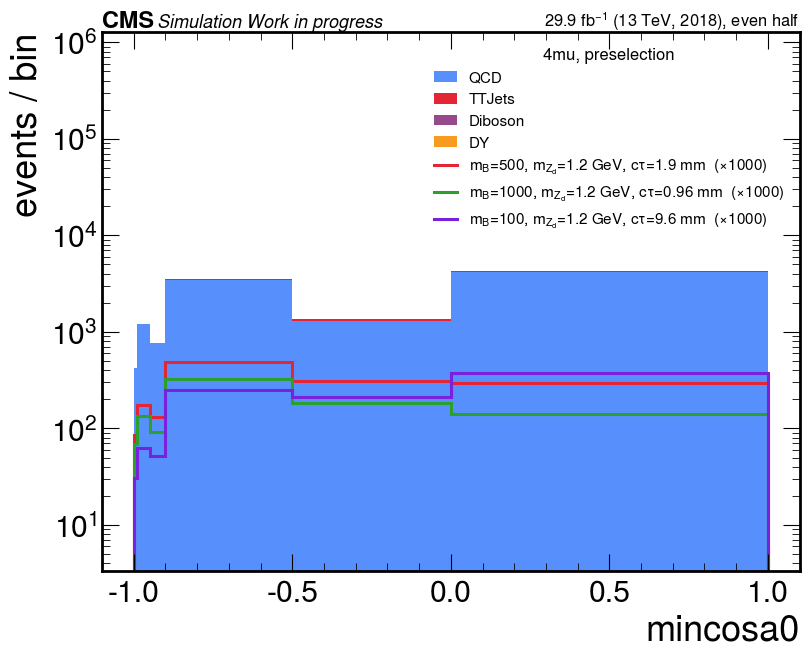

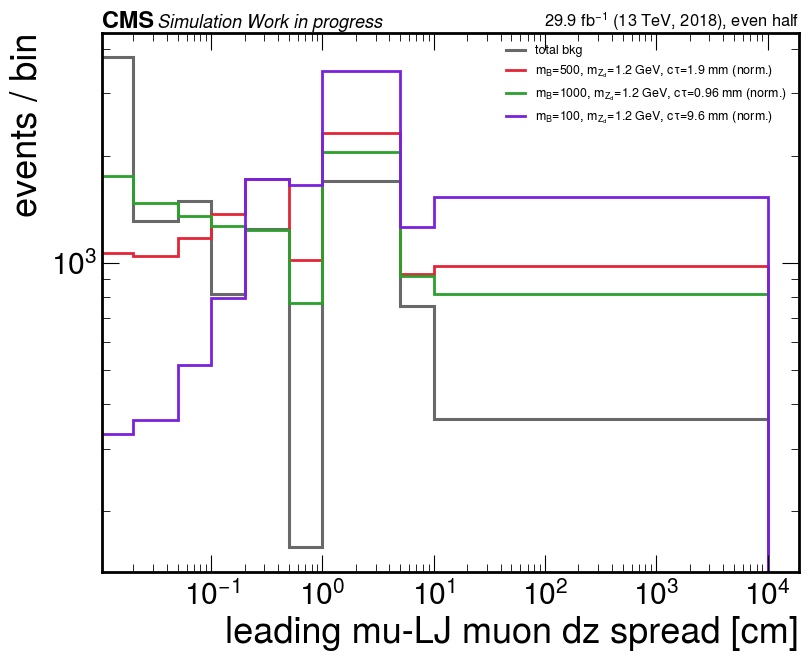

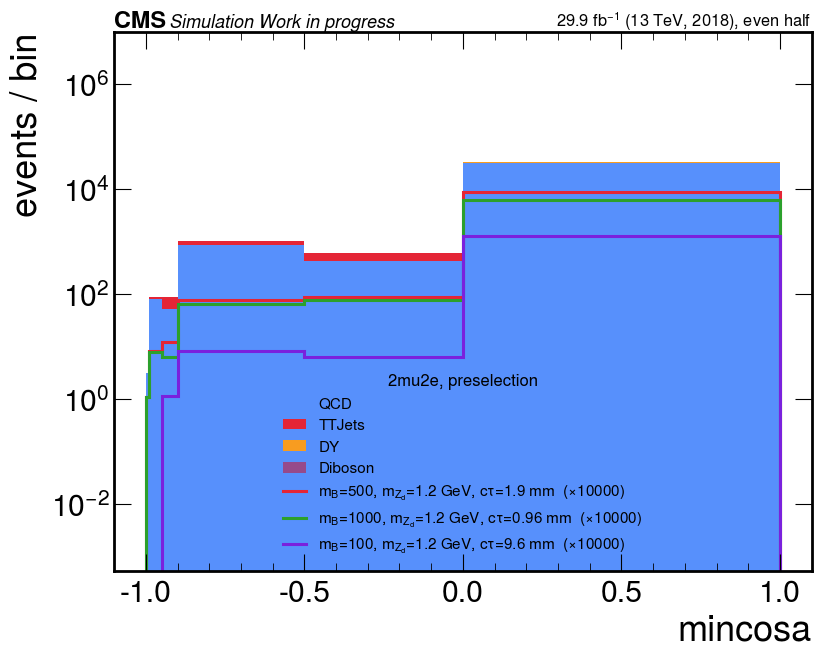

In [5]:
for ch, hname, axname in [("4mu", "abcd_cosmic_4mu", "mincosa0"),
                          ("2mu2e", "abcd_cosmic_2mu2e", "mincosa")]:
    procs = []
    for pnm in ss.PROCESSES:
        v, xe = member1d(by_process_m[pnm], hname, ch, axname)
        procs.append((pnm, v))
    procs.sort(key=lambda t: -t[1].sum())
    sig_entries = []
    for sname in SIG_SHOW[ch]:
        sh = load_sig_m(sname)
        v, sxe = member1d(sh, hname, ch, axname)
        del sh
        if v.sum() <= 0:
            continue
        smax = max(t[1].sum() for t in procs)
        scale = 10 ** max(0, int(np.round(np.log10(smax / max(v.sum(), 1e-12) / 10))))
        sig_entries.append((sname, v, scale))
    ph.stack1d(procs, xe, xname=axname, signal_entries=sig_entries,
               note=f"{ch}, preselection", ylabel="events / bin", sentinel=False)
    if ch == "4mu":
        v, xe = member1d(total_bkg_m, hname, ch, "dzspread0")
        fig, axx = plt.subplots()
        axx.stairs(v, xe, color="dimgray", lw=2.2, label="total bkg")
        for sname in SIG_SHOW[ch]:
            sh = load_sig_m(sname)
            sv, sxe = member1d(sh, hname, ch, "dzspread0")
            del sh
            if sv.sum() > 0:
                axx.stairs(sv * v.sum() / sv.sum(), sxe, lw=2,
                           color=ph.MASS_COLORS[ph.parse_sig(sname)[0]],
                           label=ph.sig_label(sname) + " (norm.)")
        axx.set_xscale("log"); axx.set_yscale("log")
        axx.set_xlabel("leading mu-LJ muon dz spread [cm]")
        axx.set_ylabel("events / bin")
        axx.legend(fontsize=9, framealpha=0.85)
        cms_label(axx)
        plt.show()

### Signal cost of a candidate cos α threshold

The cos α axis was binned during the member campaign with edges at
−0.999, −0.99, −0.95, −0.9; a tight veto near cos α ≈ −0.98 — the mop-up
threshold for the most back-to-back (cosmic-like) pairs — therefore lands
**between the −0.99 and −0.95 bins**, so its exact cost brackets between those
two working points below. Refining the binning around −0.98 (and adding the
per-LJ vxy spread) is deferred to the next processing pass, alongside the check
of whether a single common member-spread threshold suffices for both PF and DSA
muons.

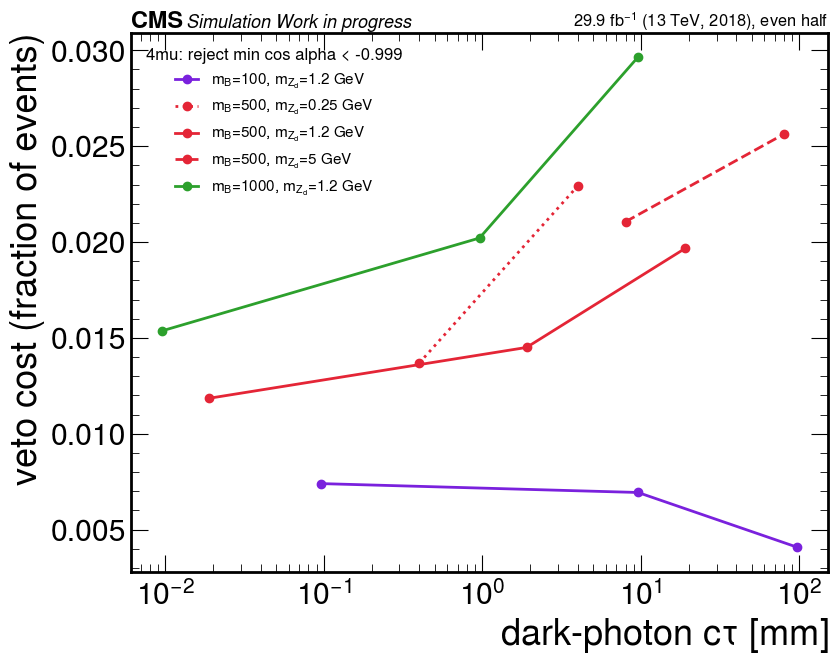

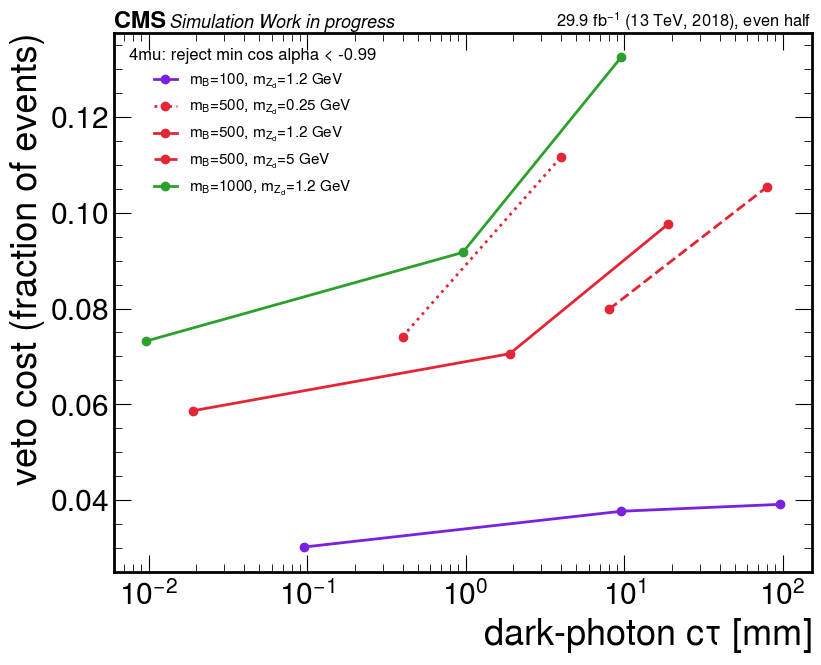

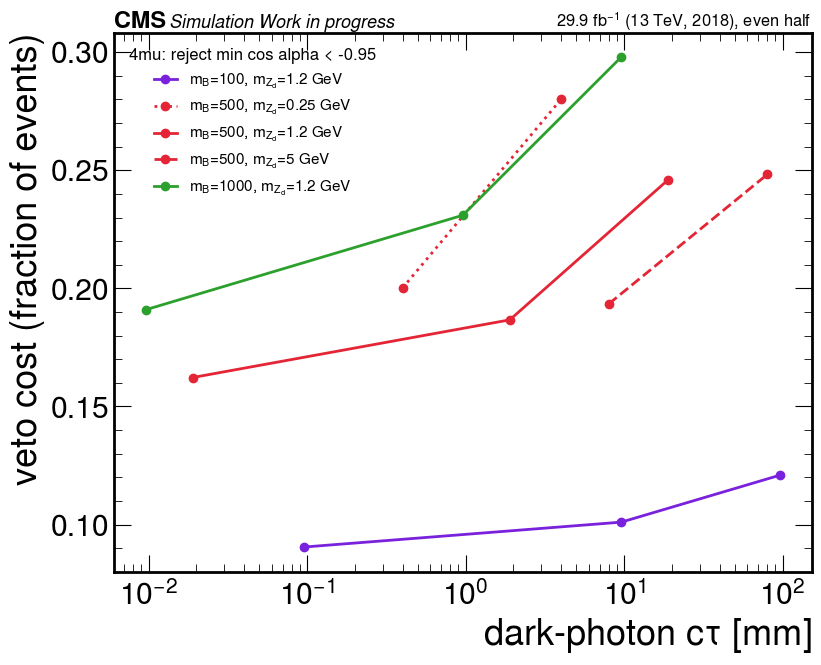

4mu: bkg fraction with mincosa < -0.99: 4.782%


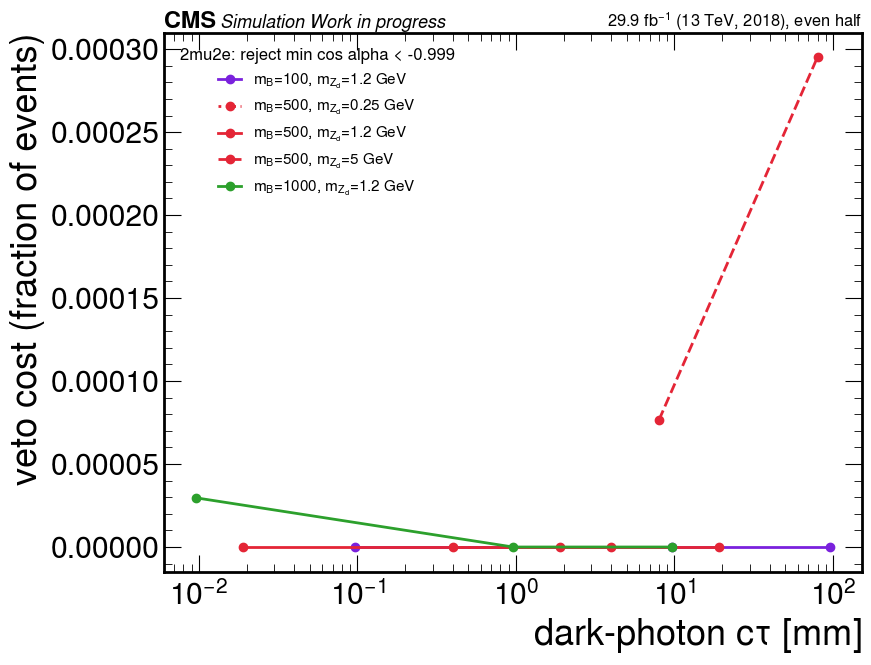

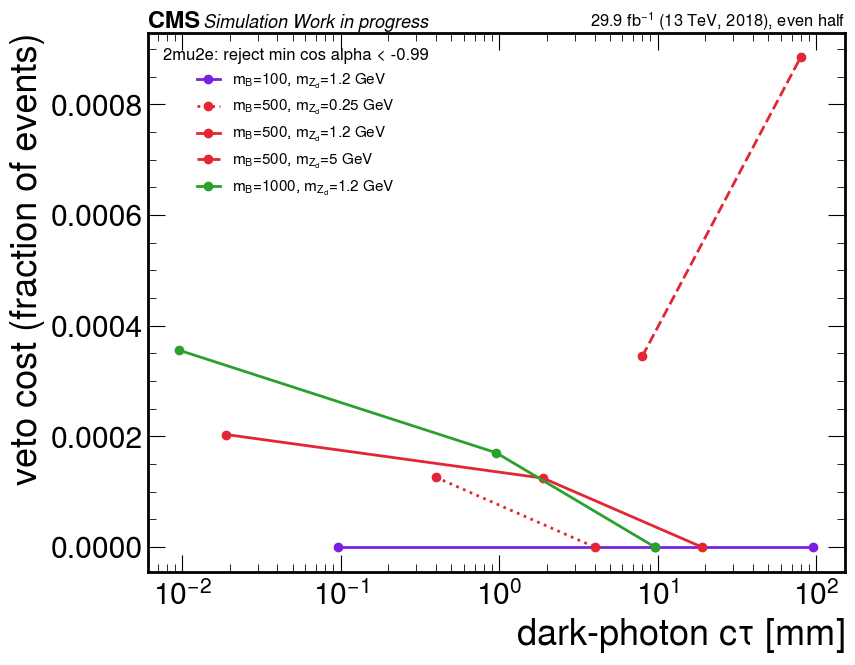

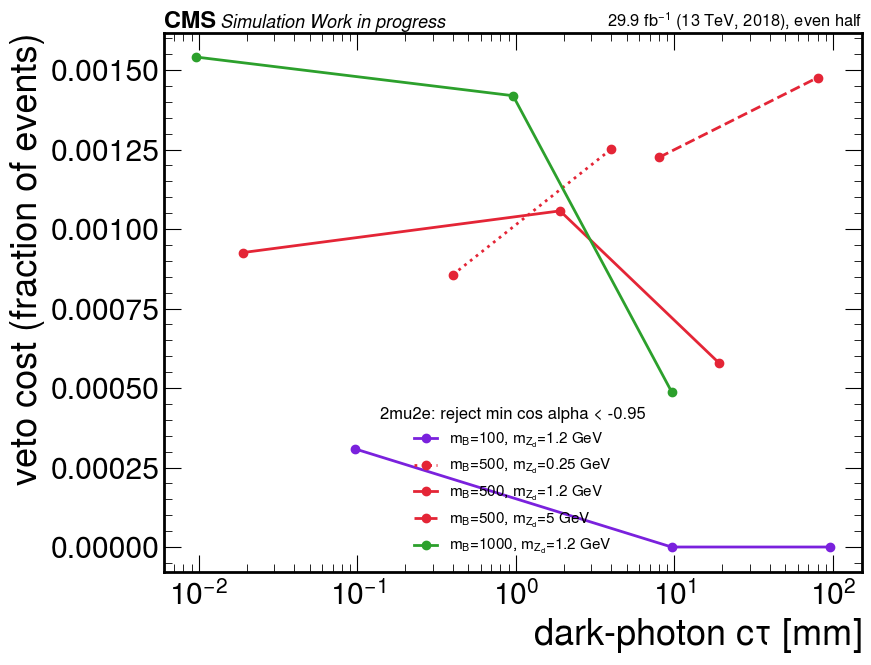

2mu2e: bkg fraction with mincosa < -0.99: 0.020%


In [6]:
for ch, hname, axname, sigs in [("4mu", "abcd_cosmic_4mu", "mincosa0", ss.SIGNALS_4MU),
                                ("2mu2e", "abcd_cosmic_2mu2e", "mincosa", ss.SIGNALS_2MU2E)]:
    for thr in (-0.999, -0.99, -0.95):
        costs = {}
        for sname in sigs:
            sh = load_sig_m(sname)
            v, xe = member1d(sh, hname, ch, axname)
            del sh
            tot = v.sum()
            if tot <= 0:
                continue
            icut = at.edge_index(xe, thr)
            costs[sname] = v[:icut].sum() / tot
        if costs:
            ph.eff_vs_ctau(costs, ylabel="veto cost (fraction of events)",
                           note=f"{ch}: reject min cos alpha < {thr}", ylog=False)
    print(f"{ch}: bkg fraction with mincosa < -0.99:", end=" ")
    v, xe = member1d(total_bkg_m, hname, ch, axname)
    print(f"{v[:at.edge_index(xe, -0.99)].sum() / max(v.sum(), 1e-300):.3%}")

## Findings

Numbers are the even half on the partial member-campaign merge (2018 MC) and carry
no per-bin uncertainties yet — read the fractions below as provisional until the
full merge with errors.

**Mother composition: the dominant components transport consistently along mJJ; the
subdominant ones are inconclusive.** Every region is majority b-hadron (labels: A
63%, B 69%, C 56%, D 65% — but see the caveat below), with prompt, light-hadron/
decay-in-flight (DIF), and c-hadron muons making up the rest. The microscopic
condition behind ABCD is that the *change along the isolation axis* be the same at
high and low mJJ. It holds cleanly for the two dominant components: going tight→loose
in isolation, the prompt fraction changes by −16 points at both high mJJ (18%→2%,
A→B) and low mJJ (19%→3%, C→D) — identical — and b changes by +6 and +9 points, close.
It does **not** hold for the two subdominant components: light/DIF changes by +11
points at high mJJ but −13 at low mJJ, and c by −4 vs +11 — opposite signs. Because
prompt+b are ~75–85% of every region these opposite-sign tails are a small effect,
and on partial even-half statistics with no errors they may well be noise; but they
are a real caveat, not a clean validation, and must be re-checked with uncertainties
on the full merge. The independence *gate* (the χ² p-value test of notebook 02,
which the jet-based plane passed) remains the operative validation; this composition
study is a supporting cross-check that is broadly consistent for the bulk of the
background and flags the subdominant flavors for follow-up.

*Labeling caveat:* each mu-LJ is tagged by the **highest-priority** gen match among
its muons (b > c > tau > light/DIF > prompt > fake), so "b-dominated" partly reflects
that one b-matched muon labels the whole LJ; the fake/unmatched fractions are lower
bounds. The DSA-only category (no PF muon, hence no genPartFlav) is ≤5% of each
region (A 1%, B 3%, C 0%, D 5%) — it carries no flavor of its own; the remaining
labeled background in those regions is b-dominated.

**The cosmic-veto *cost* is small, but the variable does not isolate cosmics on its
own.** A cut on min cos α < −0.99 removes essentially 0% of 2mu2e signal and 0.02% of
2mu2e MC background; for 4mu it removes ≈3–4% of signal and 4.8% of MC background,
rising to ≈9–10% / 15% at the looser −0.95. Crucially, **none of these MC numbers is
a cosmic-rejection estimate — MC contains no cosmics.** They are the response of a
*physics* variable: min cos α finds the most back-to-back muon pair in the event, and
in the 4mu channel the two recoiling dark-photon lepton jets are themselves
back-to-back, so an LJ-1 muon against an LJ-2 muon gives cos α ≈ −1. The 4mu "cost" is
therefore self-veto by the signal's own di-LJ topology (which is why 2mu2e, with a
single muonic LJ, costs ~0), and the 4mu MC-background rate at cos α < −0.99 is
ordinary back-to-back physics dimuons (Drell–Yan, jet recoil), not cosmics. **To
become a clean cosmic tag this variable must exclude muons belonging to the
reconstructed signal LJs** (consider only the *extra* muons in the event as candidate
cosmic partners) — a refinement for the next processing pass, together with the per-LJ
vxy spread and a finer cos α binning near the −0.98 working point (which currently
brackets between the −0.99 and −0.95 values). The per-LJ dz spread is signal-cheap and
does not suffer this topology confusion. As always, the veto's actual rejection power
must be measured in a cosmic-enriched data sideband (Phase 3).

*Partial-merge caveat:* 35/1699 chunks were transiently unreadable during an EOS
storage-node outage; the merge normalizes by the Σw of included chunks, so the
fractions are unbiased in expectation (lower effective stats), and refresh when the
full merge completes. DYJetsToMuMu_M50 is excluded throughout (rogue generator
weights contaminate its skims; see study_setup); DY M10to50 is retained.